# OPLS via PLS-CCA

The `cca=True` flag in `phi.pls()` computes covariant (predictive) scores and loadings equivalent to OPLS. The covariant scores `Tcv` and loadings `Pcv` isolate Y-relevant variation; orthogonal components capture the rest.

Reference: Yu & MacGregor.

In [1]:
import pandas as pd
import numpy as np
import pyphi.calc as phi
import pyphi.plots as pp
import matplotlib.pyplot as plt
from bokeh.io import output_notebook
output_notebook(hide_banner=True)
import pyphi.plots as _ppmod
_ppmod.output_file = lambda *a, **kw: None
%matplotlib inline


Will be using the NEOS server in the absence of IPOPT and GAMS


## Load Data

In [2]:
X_df = pd.read_excel('../data/OPLS Test Data.xlsx', 'X')
Y_df = pd.read_excel('../data/OPLS Test Data.xlsx', 'Y')
print('X:', X_df.shape, '  Y:', Y_df.shape)
# Convert to numpy arrays (this dataset has no obs-ID column)
X = X_df.values
Y = Y_df.values


X: (120, 100)   Y: (120, 1)


## Build PLS with CCA flag

In [3]:
pls_cca = phi.pls(X, Y, 5, cca=True)
print('Extra keys added by cca=True:', [k for k in pls_cca if k not in ['T','P','Q','W','Ws','r2x','r2y']])
print('Tcv shape:', pls_cca['Tcv'].shape)
print('Pcv shape:', pls_cca['Pcv'].shape)


phi.pls using NIPALS executed on: 2026-03-27 00:05:05.230614
# Iterations for LV #1:  1
# Iterations for LV #2:  1
# Iterations for LV #3:  1
# Iterations for LV #4:  1
# Iterations for LV #5:  1
--------------------------------------------------------------
LV #     Eig       R2X       sum(R2X)   R2Y       sum(R2Y)
LV #1:   23.576    0.289     0.289      0.339     0.339
LV #2:    5.624    0.116     0.405      0.309     0.648
LV #3:   11.248    0.196     0.601      0.161     0.809
LV #4:   27.101    0.274     0.875      0.048     0.857
LV #5:   10.953    0.123     0.998      0.000     0.857
--------------------------------------------------------------
Extra keys added by cca=True: ['U', 'r2xpv', 'mx', 'sx', 'r2ypv', 'my', 'sy', 'var_t', 'T2', 'T2_lim99', 'T2_lim95', 'speX', 'speX_lim99', 'speX_lim95', 'speY', 'speY_lim99', 'speY_lim95', 'Tcv', 'Pcv', 'Wcv', 'Betacv', 'type']
Tcv shape: (120, 1)
Pcv shape: (100, 1)


## Covariant (Predictive) Loadings

`Pcv` is equivalent to OPLS predictive loadings. They isolate the X-variation correlated with Y.

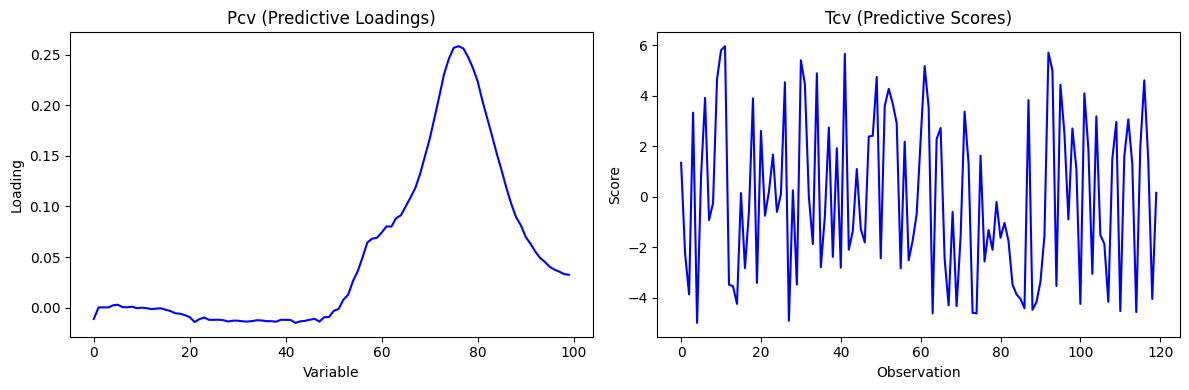

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(pls_cca['Pcv'], 'b-')
axes[0].set_title('Pcv (Predictive Loadings)')
axes[0].set_xlabel('Variable')
axes[0].set_ylabel('Loading')

axes[1].plot(pls_cca['Tcv'], 'b-')
axes[1].set_title('Tcv (Predictive Scores)')
axes[1].set_xlabel('Observation')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()


## Score and Loadings Plots via pyphi.plots

In [5]:
pp.score_scatter(pls_cca, [1, 2])
pp.loadings(pls_cca)
pp.r2pv(pls_cca)
